# 05. 2차 모델링 : LightGBM

# 작업 순서

1. LightGBM 베이스라인 모델 학습
2. 피처 중요도 확인
3. LightGBM 결과 해석

## 사용 피처셋

| 변수명 | 포함 근거 |
|---|---|
| log_전용면적 | 면적-가격 비선형 관계 반영을 위한 로그변환 |
| 층 | MLR에서 유의미하게 확인된 변수 |
| 주택연령 | MLR에서 유의미하게 확인된 변수 |
| is_basement | Cohen's d=1.2로 효과 견고, MLR에서는 해석상 제외되었으나 트리모델에서 복귀 |
| SK미래관거리 | 학세권 효과 반영 (안암역과 상관 높아 대리변수 한계는 있음) |
| 보문역거리 | 역세권 효과 반영 |
| 면적라벨_소형, 면적라벨_중형 | 면적 구간별 비선형 효과, 소형은 다중공선성으로 MLR에서 제외되었으나 트리모델에서 복귀 |
| 전월세구분_전세 | MLR에서 유의미(전세 시 단가 낮음) |
| 동그룹_안암동 | MLR에서 유의미성 경계선(p=0.052)이나 동네 특성 반영을 위해 유지 |
| 주택유형_연립 | MLR에서 유의미(연립이 다세대 대비 프리미엄) |


# 0. 데이터 업로드

활용 데이터셋: dataset_final_ML1조.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
print("▶ dataset_final_ML1조 파일 업로드")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

#   Train(2023) = 학습 전용 / Val(2024) = early stopping 전용 / Test(2025~2026) = 최종 평가 1회 전용
train_test_split_raw = df[df['data_split'] == 'train'].copy()
test_df = df[df['data_split'] == 'test'].copy()

train_df = train_test_split_raw[train_test_split_raw['계약연도'] == 2023].copy()
val_df = train_test_split_raw[train_test_split_raw['계약연도'] == 2024].copy()

print(f"✅ 데이터 로드 완료")
print(f"Train(2023)     : {train_df.shape[0]}건  (학습 전용)")
print(f"Val(2024)       : {val_df.shape[0]}건  (early stopping 전용)")
print(f"Test(2025~2026) : {test_df.shape[0]}건  (최종 평가, 1회만 사용)")

▶ dataset_final_ML1조 파일 업로드


Saving dataset_final_ML1조.csv to dataset_final_ML1조.csv
✅ 데이터 로드 완료
Train(2023)     : 332건  (학습 전용)
Val(2024)       : 362건  (early stopping 전용)
Test(2025~2026) : 592건  (최종 평가, 1회만 사용)


In [3]:
!sudo apt-get install -y fonts-nanum

import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("등록된 폰트 확인:", [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name])


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (37.4 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118332 files and direc

# 1. LightGBM 베이스라인 모델 학습

In [4]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 최종 피처셋 정의 (is_basement, 면적라벨_소형 복귀)
target = '면적당가격_만원'
features_gbm = [
    'log_전용면적', '층', '주택연령', 'is_basement',
    'SK미래관거리', '보문역거리',
    '면적라벨_소형', '면적라벨_중형',
    '전월세구분_전세', '동그룹_안암동', '주택유형_연립'
]

X_train = train_df[features_gbm]
y_train = train_df[target]
X_val = val_df[features_gbm]
y_val = val_df[target]
X_test = test_df[features_gbm]
y_test = test_df[target]

# LightGBM 베이스라인 학습
lgb_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=10,
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# 최종 평가 (test(2025~2026)에서 단 한 번만 수행)
y_pred = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration_)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("="*60)
print(" 🎯 [LightGBM 베이스라인] Test 데이터(25~26년) 예측 성능")
print("="*60)
print(f"▶ Test R-squared (설명력): {r2:.4f}")
print(f"▶ Test RMSE (평균 오차액): {rmse:.1f} 만원/m²")
print(f"▶ Test MAE  (절대 오차액): {mae:.1f} 만원/m²")
print(f"▶ Best iteration: {lgb_model.best_iteration_}")
print("="*60)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000335 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 264
[LightGBM] [Info] Number of data points in the train set: 332, number of used features: 10
[LightGBM] [Info] Start training from score 814.881152
 🎯 [LightGBM 베이스라인] Test 데이터(25~26년) 예측 성능
▶ Test R-squared (설명력): 0.8051
▶ Test RMSE (평균 오차액): 152.2 만원/m²
▶ Test MAE  (절대 오차액): 110.2 만원/m²
▶ Best iteration: 155


# 2. 피처 중요도 확인

 🔍 LightGBM Feature Importance (split 기준)
    Feature  Importance
   log_전용면적         565
    SK미래관거리         538
      보문역거리         333
       주택연령         298
          층         218
   전월세구분_전세         114
    면적라벨_중형          38
    주택유형_연립          35
    동그룹_안암동          31
    면적라벨_소형           0
is_basement           0


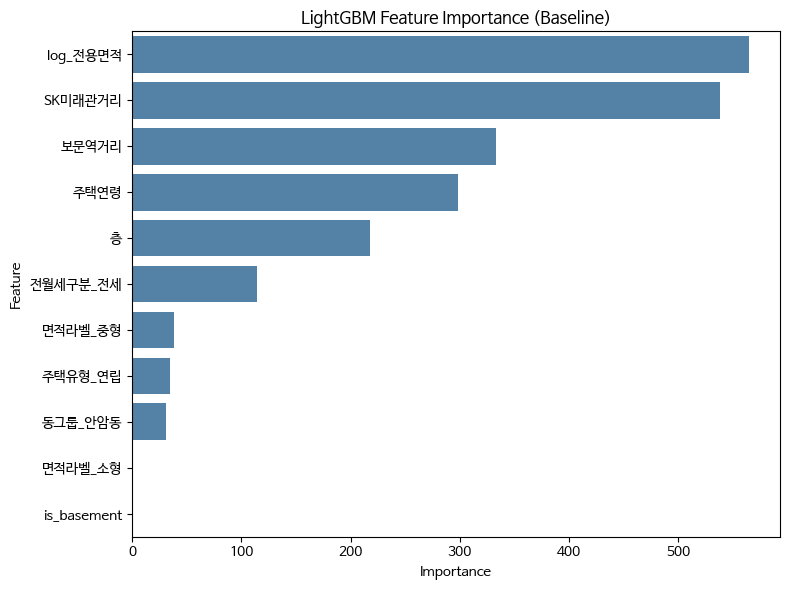

In [5]:
# Feature Importance 확인 (베이스라인 모델 기준)

importance_df = pd.DataFrame({
    'Feature': features_gbm,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*60)
print(" 🔍 LightGBM Feature Importance (split 기준)")
print("="*60)
print(importance_df.to_string(index=False))

# 시각화
plt.figure(figsize=(8,6))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='steelblue')
plt.title('LightGBM Feature Importance (Baseline)')
plt.tight_layout()
plt.show()


# 3. LightGBM 결과 해석

## 3.0 방법론 수정 이력 — 검증 데이터 분리


- Train = 계약연도 2023 (332건) — 학습 전용
- Val = 계약연도 2024 (362건) — early stopping 전용
- Test = 2025~2026 (592건) — **최종 평가에만 1회 사용, 학습/튜닝에 전혀 관여하지 않음**

## 3.1 성능 비교: MLR2 vs LightGBM vs XGBoost

| 지표 | MLR2 (최종) | LightGBM (기존, leakage 있음) | **LightGBM (재측정, 공정비교)** | XGBoost |
|---|---|---|---|---|
| Test R² | 0.649 | 0.851 | **0.805** | 0.797 |
| Test RMSE | 204.2 | 133.2 | **152.2** | 155.4 |
| Test MAE | 159.3 | 94.4 | **110.2** | 118.7 |

LightGBM의 성능: **R²=0.805**로 나타남.
XGBoost(0.797)와 비교했을 때도 근소한 우위(+0.008)를 보임.

## 2.2 Feature Importance 해석 (베이스라인 기준)

| 순위 | 변수 | Importance |
|---|---|---|
| 1 | log_전용면적 | 565 |
| 2 | SK미래관거리 | 538 |
| 3 | 보문역거리 | 333 |
| 4 | 주택연령 | 298 |
| 5 | 층 | 218 |
| 6 | 전월세구분_전세 | 114 |
| 7 | 면적라벨_중형 | 38 |
| 8 | 주택유형_연립 | 35 |
| 9 | 동그룹_안암동 | 31 |
| 10 | 면적라벨_소형 | 0 |
| 11 | is_basement | 0 |

면적, 거리(학교·역), 주택연령, 층 등 물리적·입지적 변수가 예측에 가장 크게 기여하였으며, 이는 MLR2의 유의미한 변수들과 대체로 일치하는 결과임.

**is_basement에 대한 해석**:

MLR에서는 계수 해석상의 이유로 제외되었던 `is_basement`를 본 분석에서는 복귀시킴.

그러나 재측정 결과(베이스라인, min_child_samples=10)에서 importance는 0으로, 반지하 여부가 트리 분기에 반영되지 않은 것으로 확인. 이는 반지하 표본이 14건으로 극히 적어, 학습에 사용된 Train(2023, 332건)만으로는 분기 조건(각 노드 최소 표본 수)을 만족하는 사례가 더욱 부족했기 때문으로 추정.

(기존 버전은 2023+2024를 합쳐 694건으로 학습했으나, 재측정 버전은 Train을 2023(332건)으로 한정했기 때문에 표본 부족 문제가 더 두드러짐.

**시사점**: 반지하 여부는 선형회귀 관점(Cohen's d=1.2)에서는 뚜렷한 효과가 확인되나, 표본 수 제약으로 인해 트리 기반 모델(LightGBM, XGBoost 공통)에서는 그 신호를 충분히 학습하지 못하는 한계가 있음. 이는 "통계적으로 유의미한 효과"와 "머신러닝 모델의 실질적 활용 가능성"이 표본 크기에 따라 괴리될 수 있음을 보여주는 사례이며, 반지하 표본이 특히 취약계층 주거와 관련이 깊다는 점에서 데이터 기반 심사·평가 모델이 소수 취약 유형을 놓치기 쉽다는 문제의식으로도 연결됨.

(추후 반지하 표본 확보 시 재검증 필요.)




*   ## 결과 정리 (MLR2 vs LightGBM vs XGBoost, 공정 비교)



In [6]:
results_summary = pd.DataFrame({
    'Model': ['MLR2', 'LightGBM', 'XGBoost'],
    'Test_R2': [0.649, r2, 0.7984],
    'Test_RMSE': [204.2, rmse, 154.9],
    'Test_MAE': [159.3, mae, 117.7]
})

results_summary


,Model,Test_R2,Test_RMSE,Test_MAE
0,MLR2,0.649000,204.200000,159.300000
1,LightGBM,0.805114,152.247378,110.224464
2,XGBoost,0.798400,154.900000,117.700000


In [7]:
# LightGBM 예측값 저장 (베이스라인 모델 기준, 07_xgboost_predictions.csv와 동일 포맷)

predictions_df = pd.DataFrame({
    'data_split': test_df['data_split'].values,
    'row_id': test_df.index,
    'actual': y_test.values,
    'lgb_pred': y_pred,
})

predictions_df.to_csv('lightgbm_predictions.csv', index=False)

from google.colab import files
files.download('lightgbm_predictions.csv')

predictions_df.head()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,data_split,row_id,actual,lgb_pred
0,test,694,734.693878,920.076945
1,test,695,1385.615671,1402.265621
2,test,696,1182.658444,1239.457141
3,test,697,426.621160,432.827325
4,test,698,984.638597,819.103159


--------------------------------------------------------------------------------




--------------------------------------------------------------------------------

## 추가 탐색: '`is_basement`' 반영 실험 (v2, min_child_samples=3)

이 실험은 "표본이 극히 적은(14건) is_basement가 min_child_samples를 낮추면 트리 분기에 반영될 수 있는지"를 확인하기 위한 추가 탐색임.

In [8]:
lgb_model_v2 = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=3,    # 10 -> 3, 표본 적은 is_basement 분기 허용 위해 완화
    random_state=42
)

lgb_model_v2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

y_pred_v2 = lgb_model_v2.predict(X_test, num_iteration=lgb_model_v2.best_iteration_)

rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))
mae_v2 = mean_absolute_error(y_test, y_pred_v2)
r2_v2 = r2_score(y_test, y_pred_v2)

print("="*60)
print(" 🎯 [참고 실험: min_child_samples=3] Test 성능")
print("="*60)
print(f"▶ Test R-squared: {r2_v2:.4f}  (베이스라인: {r2:.4f})")
print(f"▶ Test RMSE: {rmse_v2:.1f}  (베이스라인: {rmse:.1f})")
print(f"▶ Test MAE: {mae_v2:.1f}  (베이스라인: {mae:.1f})")
print("="*60)

importance_df_v2 = pd.DataFrame({
    'Feature': features_gbm,
    'Importance': lgb_model_v2.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔍 Feature Importance (참고 실험)")
print(importance_df_v2.to_string(index=False))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 266
[LightGBM] [Info] Number of data points in the train set: 332, number of used features: 11
[LightGBM] [Info] Start training from score 814.881152
 🎯 [참고 실험: min_child_samples=3] Test 성능
▶ Test R-squared: 0.8031  (베이스라인: 0.8051)
▶ Test RMSE: 153.0  (베이스라인: 152.2)
▶ Test MAE: 111.5  (베이스라인: 110.2)

🔍 Feature Importance (참고 실험)
    Feature  Importance
   log_전용면적        1086
    SK미래관거리         670
      보문역거리         561
          층         531
       주택연령         468
   전월세구분_전세         158
    면적라벨_중형          73
    동그룹_안암동          37
    주택유형_연립          27
    면적라벨_소형          15
is_basement           0
